In [111]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import signal
import ast

# Load all data
all_eeg = []
all_aux = []
all_mark = []
all_inds = []
for run in range(1, 9):
    eeg = np.load(f"person-1eeg_2-per-class_run-{run}.npy")
    aux = np.load(f"person-1aux_2-per-class_run-{run}.npy")
    mark = np.load(f"person-1markers_2-per-class_run-{run}.npy")
    with open(f"person-1tar_inds_2-per-class_run-{run}.txt", "r") as f:
        first_line = f.readline()
    target_inds = ast.literal_eval(first_line)
    all_eeg.append(eeg)
    all_aux.append(aux)
    all_mark.append(mark)
    all_inds.append(target_inds)
    
    # print('eeg', eeg.shape)
    # print('aux', aux.shape)
    # print('markers', mark.shape)
    # print('indices', target_inds)

In [112]:
all_runs_trigger = []
all_runs_mark = []

for run in range(8):
    # Calculate stim indices from the trigger
    threshold = 78
    trigger = all_aux[run][1, :]
    temp_trials = np.where(trigger > threshold)[0]
    all_trials_trigger = [temp_trials[0]]
    
    # Need to filter out the false stimulation triggers
    for trial in temp_trials[1:]:
        if trial - all_trials_trigger[-1] >= 10:
            all_trials_trigger.append(trial)
    all_trials_trigger = np.array(all_trials_trigger)
    all_runs_trigger.append(all_trials_trigger)
    
    # Calculate stim indices from the markers
    all_trials_mark = np.where(mark > 0)[0]
    all_runs_mark.append(all_runs_mark)

In [113]:
# Calculate sampling rate
sample_diff = all_runs_trigger[0][1] - all_runs_trigger[0][0]
time_diff = 0.85 # 0.3s for trial, 0.5s for in between trial, Average 0.5s from jitter

fs = sample_diff / time_diff
dt = 1000 / fs

print(fs)
print(dt)

# Define ERP-related variables
channels = np.array(['O1', 'O2', 'T5', 'P3', 'Pz', 'P4', 'T6', 'REF'])
epoch_start = 0    # ms
epoch_end = 700    # ms
baseline_start = 0 # ms
baseline_end = 200 # ms
erp_start = 200    # ms
erp_end = 400      # ms
hp = 0.1           # Hz; our low cut for our bandpass
lp = 30            # Hz; our high cut for our bandpass
baseline_duration = 0.2
baseline_duration_samples = int(baseline_duration * fs)
num_taps = 100
b = signal.firwin(numtaps=num_taps, cutoff=[hp, lp], pass_zero='bandpass', fs=fs)
a = 1

242.3529411764706
4.126213592233009


In [114]:
# Filter and clean the eeg data
ref_ind = np.where(channels == 'REF')[0][0]
eeg_runs = []

for run in range(8):
    eeg_trials = [[],[],[],[],[],[],[],[]]
    
    for i, c in enumerate(channels):
        referenced_eeg = all_eeg[run] - all_eeg[run][ref_ind] # Subtract reference from all channels
        filtered_eeg = signal.filtfilt(b, a, referenced_eeg[i])
        # filtered_eeg = signal.filtfilt(b, a, all_eeg[run][i])
        
        for j, trial in enumerate(all_runs_trigger[run]):
            if 1 < j < 96: # Need to discard trials at the end because there aren't enough samples
                trial_start = int(trial - baseline_duration_samples)
                trial_duration = int(int(dt * fs) + baseline_duration_samples)
                trial_eeg = np.copy(filtered_eeg[trial_start:trial_start+trial_duration])
                baseline_average = np.mean(trial_eeg[:baseline_duration_samples])
                trial_eeg -= baseline_average        
                eeg_trials[i].append(trial_eeg)
    eeg_runs.append(eeg_trials)

In [115]:
# Convert lists to numpy arrays
eeg_runs = np.array(eeg_runs, dtype=object)

# Containers
known_trials = []
unknown_trials = []

for run in range(8):

    trials = all_runs_trigger[run]

    for j, trial in enumerate(trials):

        if 1 < j < 96:

            if j in all_inds[run]:
                known_trials.append([eeg_runs[run][ch][j-2] for ch in range(len(channels))])
            else:
                unknown_trials.append([eeg_runs[run][ch][j-2] for ch in range(len(channels))])

known_trials = np.array(known_trials)
unknown_trials = np.array(unknown_trials)

print("Known trials:", known_trials.shape)
print("Unknown trials:", unknown_trials.shape)

Known trials: (78, 8, 1048)
Unknown trials: (674, 8, 1048)


In [116]:
erp_known = np.mean(known_trials, axis=0)
erp_unknown = np.mean(unknown_trials, axis=0)

time = np.linspace(-baseline_duration, epoch_end/1000, erp_known.shape[1])

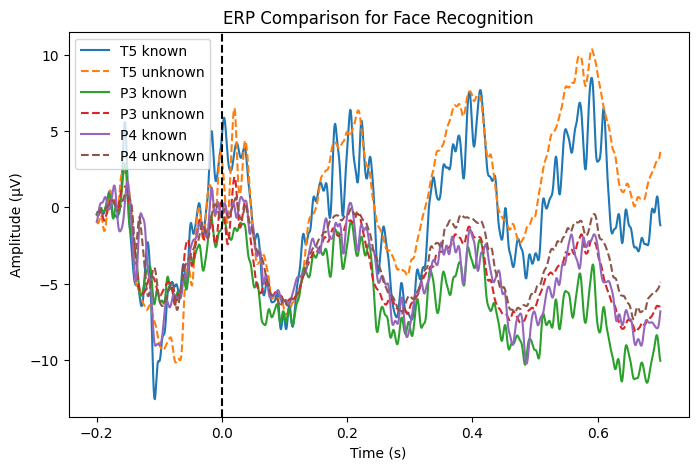

In [117]:
electrodes = ['T5','P3','P4']

plt.figure(figsize=(8,5))

for e in electrodes:

    ch = np.where(channels == e)[0][0]

    plt.plot(time, erp_known[ch], label=f"{e} known")
    plt.plot(time, erp_unknown[ch], linestyle='--', label=f"{e} unknown")

plt.axvline(0,color='black',linestyle='--')

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title("ERP Comparison for Face Recognition")

plt.legend()
plt.show()

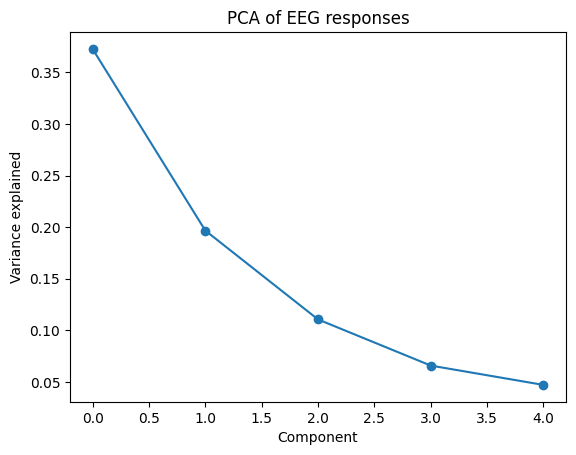

In [118]:
from sklearn.decomposition import PCA

# reshape trials
X = known_trials.reshape(known_trials.shape[0], -1)

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

plt.figure()

plt.plot(pca.explained_variance_ratio_, 'o-')

plt.xlabel("Component")
plt.ylabel("Variance explained")
plt.title("PCA of EEG responses")

plt.show()

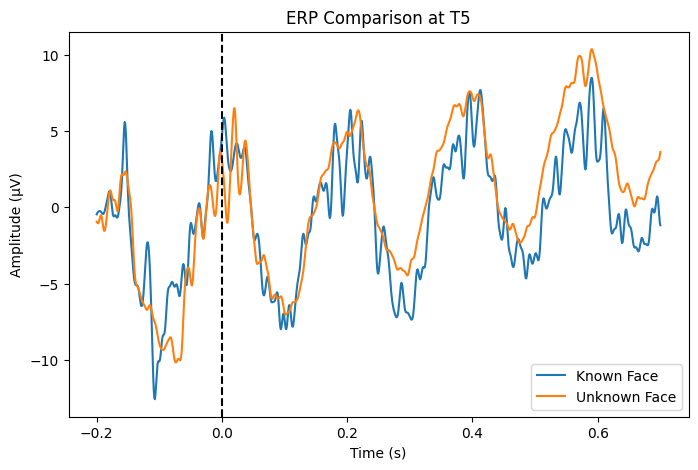

In [135]:
# choose electrode
ch = np.where(channels == 'T5')[0][0]

plt.figure(figsize=(8,5))

plt.plot(time, erp_known[ch], label="Known Face")
plt.plot(time, erp_unknown[ch], label="Unknown Face")

plt.axvline(0, linestyle='--', color='black')

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title("ERP Comparison at T5")

plt.legend()

plt.show()

In [136]:
# reshape trials
X_known = known_trials.reshape(known_trials.shape[0], -1)
X_unknown = unknown_trials.reshape(unknown_trials.shape[0], -1)

# combine both conditions
X = np.vstack([X_known, X_unknown])

labels = np.array([1]*len(X_known) + [0]*len(X_unknown))

In [137]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X)

print("Variance explained:", pca.explained_variance_ratio_)

Variance explained: [0.40257799 0.19702358 0.093379  ]


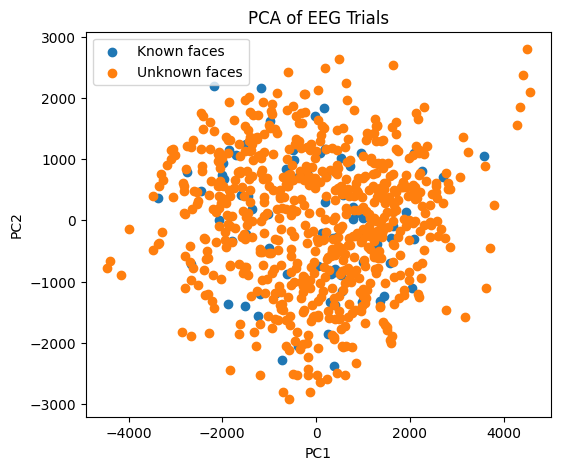

In [138]:
plt.figure(figsize=(6,5))

plt.scatter(X_pca[labels==1,0],
            X_pca[labels==1,1],
            label="Known faces")

plt.scatter(X_pca[labels==0,0],
            X_pca[labels==0,1],
            label="Unknown faces")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of EEG Trials")

plt.legend()
plt.show()

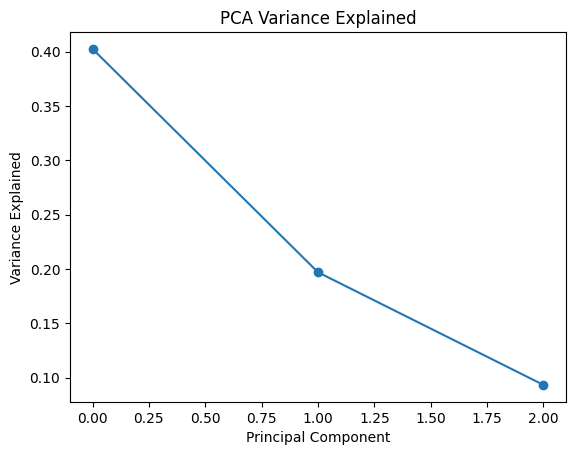

In [139]:
plt.figure()

plt.plot(pca.explained_variance_ratio_, 'o-')

plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")

plt.title("PCA Variance Explained")

plt.show()

In [140]:
pc1 = pca.components_[0].reshape(len(channels), -1)
pc2 = pca.components_[1].reshape(len(channels), -1)

In [141]:
time = np.linspace(-baseline_duration, epoch_end/1000, erp_known.shape[1])

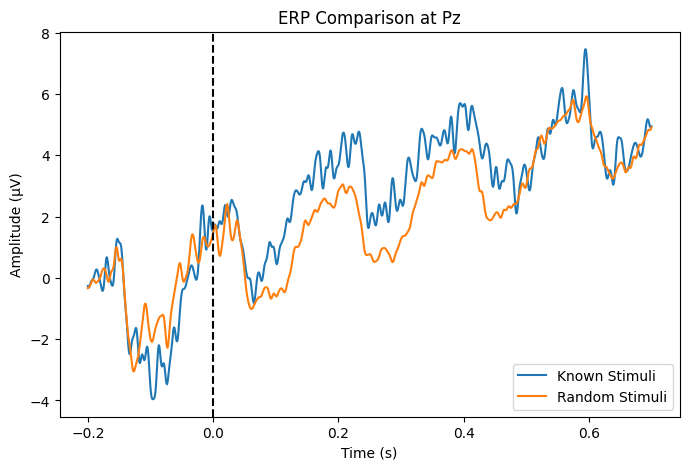

In [129]:
ch = np.where(channels == 'Pz')[0][0]

plt.figure(figsize=(8,5))

plt.plot(time, erp_known[ch], label="Known Stimuli")
plt.plot(time, erp_unknown[ch], label="Random Stimuli")

plt.axvline(0, linestyle='--', color='black')

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title("ERP Comparison at Pz")

plt.legend()
plt.show()

In [130]:
window = np.where((time >= 0.2) & (time <= 0.4))[0]

In [131]:
ch = np.where(channels == 'T5')[0][0]

In [132]:
known_amp = np.mean(known_trials[:, ch, :][:, window], axis=1)
unknown_amp = np.mean(unknown_trials[:, ch, :][:, window], axis=1)

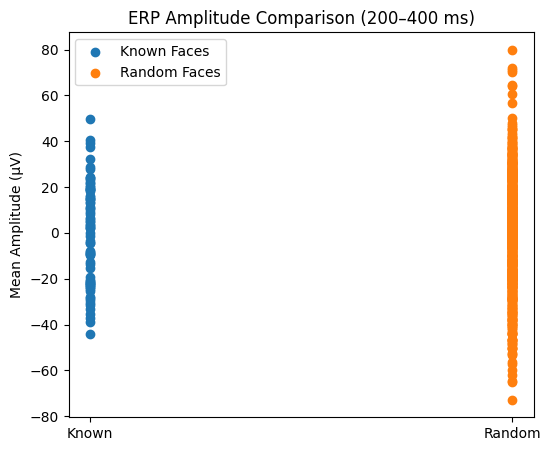

In [133]:
plt.figure(figsize=(6,5))

x_known = np.ones(len(known_amp))
x_unknown = np.ones(len(unknown_amp))*2

plt.scatter(x_known, known_amp, label="Known Faces")
plt.scatter(x_unknown, unknown_amp, label="Random Faces")

plt.xticks([1,2], ["Known","Random"])

plt.ylabel("Mean Amplitude (µV)")
plt.title("ERP Amplitude Comparison (200–400 ms)")

plt.legend()
plt.show()

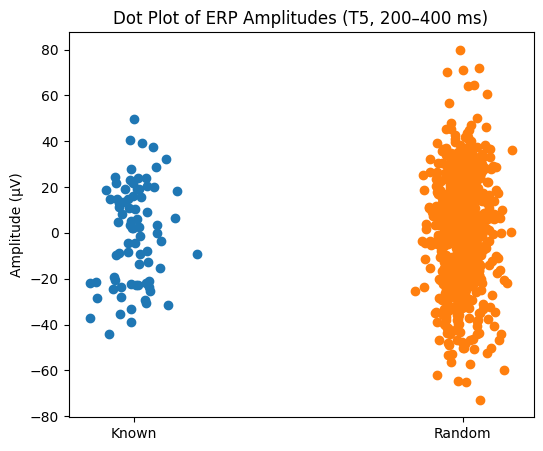

In [134]:
plt.figure(figsize=(6,5))

jitter = 0.05

plt.scatter(1 + jitter*np.random.randn(len(known_amp)), known_amp)
plt.scatter(2 + jitter*np.random.randn(len(unknown_amp)), unknown_amp)

plt.xticks([1,2], ["Known","Random"])

plt.ylabel("Amplitude (µV)")
plt.title("Dot Plot of ERP Amplitudes (T5, 200–400 ms)")

plt.show()